# Notebook 04 — Model Selection & Training
**XGBoost + LightGBM ensemble with asymmetric PHM loss**

In [ ]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from src.config import TRAIN_PATH, UNITS_PATH, TOP_N_FEATURES, RANDOM_SEED, ARTIFACTS_DIR
from src.data_loader import load_and_validate_data, detect_sensor_columns
from src.label_engineer import RULLabelEngineer
from src.feature_engineer import PumpFeatureEngineer, select_features_by_importance
from src.model import RULEnsemble, phm_score, calibrate_failure_prob
from src.validation import UnitLevelValidator, compute_metrics, progressive_accuracy_analysis
from src.eda_utils import select_rul_max_empirically
from src.utils import save_pickle
print("Imports OK")


Imports OK


In [ ]:
# Full pipeline setup
train_df, units_df = load_and_validate_data(TRAIN_PATH, UNITS_PATH)
sensor_cols, _ = detect_sensor_columns(train_df)
rul_max = select_rul_max_empirically(train_df, units_df, sensor_cols, plot=False)

le = RULLabelEngineer(rul_max=rul_max)
df_labeled = le.fit_transform(train_df, units_df)

fe = PumpFeatureEngineer(sensor_cols=sensor_cols)
fe.fit(df_labeled)
df_features = fe.transform(df_labeled)
df_features, _ = fe.drop_high_nan_features(df_features)

meta_cols = ['unit_id','cycle','rul','raw_rul','sample_weight','in_degradation_window']
cand = [c for c in df_features.select_dtypes(include="number").columns if c not in meta_cols]
feature_cols = select_features_by_importance(
    df_features[cand], df_features['rul'].values,
    df_features['sample_weight'].values, top_n=TOP_N_FEATURES
)
print(f"Pipeline ready. {len(feature_cols)} features selected.")


00:53:50 [data_loader] INFO: Loading training data…
00:53:50 [data_loader] INFO: =======================================================
00:53:50 [data_loader] INFO:   Units total    : 80
00:53:50 [data_loader] INFO:   Failed         : 72  |  Censored: 8
00:53:50 [data_loader] INFO:   Total rows     : 16,603
00:53:50 [data_loader] INFO:   Lifetime min   : 100  mean: 208  max: 339 cycles
00:53:51 [data_loader] INFO:   Missing values : 14,978  (4.51%)
00:53:51 [data_loader] INFO: =======================================================
00:53:51 [data_loader] INFO: Detected 15 sensor cols, 2 operational cols
00:53:51 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=50 | failed=72 | censored=8 | p90_lifetime=284
00:53:51 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 3,600
00:53:51 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=55 | failed=72 | censored=8 | p90_lifetime=284
00:53:51 [label_engineer] INFO

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:timestamp: object

## 1. Why Asymmetric Loss?

Standard RMSE penalises early and late predictions equally.
In pump maintenance, a **late prediction** (over-estimating RUL) means the pump breaks before maintenance arrives — far more costly than a false alarm.

The PHM asymmetric score penalises late predictions ~30% more steeply.

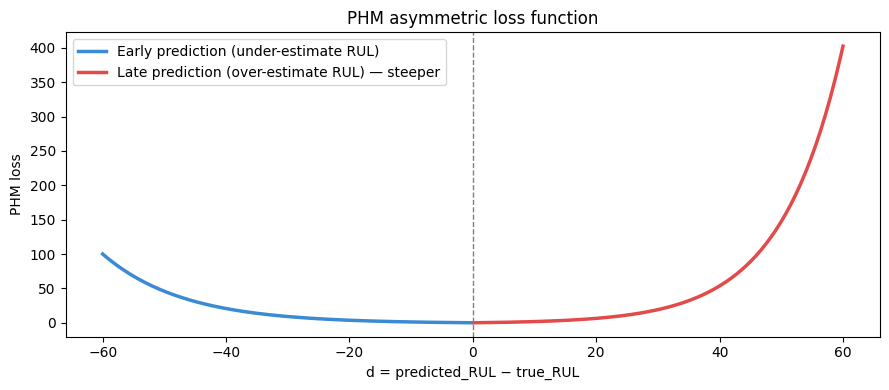

In [ ]:
# Visualise the PHM loss function
d = np.linspace(-60, 60, 300)
loss_early = np.exp(-d/13) - 1   # d < 0
loss_late  = np.exp( d/10) - 1   # d > 0
loss = np.where(d < 0, loss_early, loss_late)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d[d<0], loss[d<0], color='#3B8BD4', lw=2.5, label='Early prediction (under-estimate RUL)')
ax.plot(d[d>0], loss[d>0], color='#E24B4A', lw=2.5, label='Late prediction (over-estimate RUL) — steeper')
ax.axvline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('d = predicted_RUL − true_RUL')
ax.set_ylabel('PHM loss')
ax.set_title('PHM asymmetric loss function')
ax.legend(); plt.tight_layout(); plt.show()


## 2. Cross-Validation (GroupKFold-5)

In [ ]:
model = RULEnsemble(use_asymmetric_loss=True)
validator = UnitLevelValidator(strategy='group_kfold', n_splits=5)

print("Running 5-fold unit-level cross-validation...")
cv_results = validator.evaluate_model(df_features, feature_cols, model)
cv_results


Running 5-fold unit-level cross-validation...


NameError: name 'feature_cols' is not defined

In [ ]:
print("=" * 50)
print("CV SUMMARY")
print("=" * 50)
for col in ['rmse','mae','phm_score','within_30','late_pct']:
    print(f"  {col:15s}: {cv_results[col].mean():.2f} ± {cv_results[col].std():.2f}")
print("=" * 50)


## 3. XGBoost vs LightGBM vs Ensemble Comparison

In [ ]:
# Compare individual learners vs ensemble
results_compare = {}

for name, model_cfg in [
    ('XGBoost only',  RULEnsemble(xgb_weight=1.0, lgbm_weight=0.0)),
    ('LightGBM only', RULEnsemble(xgb_weight=0.0, lgbm_weight=1.0)),
    ('Ensemble 50/50', RULEnsemble(xgb_weight=0.5, lgbm_weight=0.5)),
]:
    cv = validator.evaluate_model(df_features, feature_cols, model_cfg)
    results_compare[name] = {
        'RMSE': cv['rmse'].mean(), 'PHM': cv['phm_score'].mean(),
        'Within30%': cv['within_30'].mean()
    }

comp_df = pd.DataFrame(results_compare).T
print(comp_df.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['RMSE','PHM','Within30%']):
    comp_df[col].plot.bar(ax=ax, color=['#3B8BD4','#1D9E75','#E24B4A'], alpha=0.8)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle('Model comparison: individual vs ensemble', y=1.01)
plt.tight_layout(); plt.show()


NameError: name 'feature_cols' is not defined

## 4. Train Final Model on Full Dataset

In [ ]:
X_all = df_features[feature_cols].fillna(0).values
y_all = df_features['rul'].values
w_all = df_features['sample_weight'].values

final_model = RULEnsemble(xgb_weight=0.5, lgbm_weight=0.5, use_asymmetric_loss=True)
final_model.fit(X_all, y_all, sample_weight=w_all)
print("Final model trained on all data.")


NameError: name 'feature_cols' is not defined

## 5. Feature Importance (Top 30)

In [ ]:
imp_df = final_model.feature_importance_df(feature_cols).head(30)
fig, ax = plt.subplots(figsize=(10, 8))
imp_df[::-1].plot.barh(x='feature', y='combined', ax=ax,
                        color='#1D9E75', alpha=0.8, legend=False)
ax.set_xlabel('Normalised combined importance')
ax.set_title('Top 30 features by ensemble importance')
plt.tight_layout(); plt.show()
print(imp_df[['feature','combined']].head(10).to_string(index=False))


NameError: name 'final_model' is not defined

## 6. Progressive Accuracy (Warning Horizon Analysis)

In [ ]:
# Use a held-out fold to check accuracy vs RUL bucket
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(df_features, groups=df_features['unit_id'].values))
tr_idx, te_idx = splits[-1]  # Last fold as held-out

df_te = df_features.iloc[te_idx].copy()
X_tr = df_features.iloc[tr_idx][feature_cols].fillna(0).values
y_tr = df_features.iloc[tr_idx]['rul'].values
w_tr = df_features.iloc[tr_idx]['sample_weight'].values
X_te = df_te[feature_cols].fillna(0).values

val_model = RULEnsemble()
valid = ~np.isnan(y_tr)
val_model.fit(X_tr[valid], y_tr[valid], sample_weight=w_tr[valid])
te_preds = val_model.predict(X_te)

prog = progressive_accuracy_analysis(df_te, te_preds)
prog


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
prog.plot.bar(x='rul_bucket', y='rmse', ax=axes[0], color='#E24B4A', alpha=0.8)
axes[0].set_title('RMSE by RUL bucket'); axes[0].set_xlabel('RUL range')
prog.plot.bar(x='rul_bucket', y='within_30', ax=axes[1], color='#1D9E75', alpha=0.8)
axes[1].set_title('Within-30 cycles accuracy by RUL bucket')
for ax in axes: ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print("\nKey insight: accuracy IMPROVES as we get closer to failure.")
print("This validates that our features capture the degradation signal.")


## 7. Save All Artefacts

In [ ]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
final_model.save(ARTIFACTS_DIR / 'ensemble_model.pkl')
save_pickle(fe,           ARTIFACTS_DIR / 'feature_pipeline.pkl')
save_pickle(feature_cols, ARTIFACTS_DIR / 'feature_cols.pkl')
save_pickle(le,           ARTIFACTS_DIR / 'label_engineer.pkl')

# Calibration
cal_preds = te_preds[~np.isnan(y_all[te_idx])]
cal_true  = y_all[te_idx][~np.isnan(y_all[te_idx])]
cal_params = calibrate_failure_prob(cal_preds, cal_true, horizon=30)

save_pickle({
    'sensor_cols': sensor_cols, 'rul_max': rul_max,
    'baseline_window': fe.baseline_window,
    'calibration_params': cal_params,
    'cv_rmse_mean': float(cv_results['rmse'].mean()),
    'cv_within30_mean': float(cv_results['within_30'].mean()),
}, ARTIFACTS_DIR / 'train_config.pkl')

print("All artefacts saved to:", ARTIFACTS_DIR)
